# Derm7pt Dataset Analysis

This notebook provides a comprehensive analysis of the derm7pt (7-point criteria) dermatology dataset.

## Dataset Overview
- **Source**: https://derm.cs.sfu.ca/restricted/release_v0.zip
- **Total Images**: 2,013 dermatology images
- **License**: CC BY-NC-ND 4.0 (Academic research use only)
- **Purpose**: 7-point criteria for melanoma diagnosis

## Analysis Goals
1. Load and examine metadata
2. Analyze image distribution and characteristics
3. Examine train/validation/test splits
4. Create visualizations
5. Generate insights and recommendations


In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# Set up paths
data_dir = Path("data/derm7pt")
images_dir = data_dir / "images"
meta_dir = data_dir / "meta"

print(f"Data directory: {data_dir}")
print(f"Images directory: {images_dir}")
print(f"Meta directory: {meta_dir}")
print(f"Directories exist: {data_dir.exists()}")


Data directory: data/derm7pt
Images directory: data/derm7pt/images
Meta directory: data/derm7pt/meta
Directories exist: True


## 1. Load and Examine Metadata


In [ ]:
# Load the main metadata file
meta_df = pd.read_csv(meta_dir / "meta.csv")

print("Metadata shape:", meta_df.shape)
print("\nColumn names:")
print(meta_df.columns.tolist())
print("\nFirst few rows:")
meta_df.head()


Metadata shape: (1011, 19)

Column names:
['case_num', 'diagnosis', 'seven_point_score', 'pigment_network', 'streaks', 'pigmentation', 'regression_structures', 'dots_and_globules', 'blue_whitish_veil', 'vascular_structures', 'level_of_diagnostic_difficulty', 'elevation', 'location', 'sex', 'management', 'clinic', 'derm', 'case_id', 'notes']

First few rows:


,case_num,diagnosis,seven_point_score,pigment_network,streaks,pigmentation,regression_structures,dots_and_globules,blue_whitish_veil,vascular_structures,level_of_diagnostic_difficulty,elevation,location,sex,management,clinic,derm,case_id,notes
0,1,basal cell carcinoma,0,absent,absent,absent,absent,absent,absent,arborizing,medium,nodular,abdomen,female,excision,NEL/NEL025.JPG,NEL/Nel026.jpg,NaN,NaN
1,2,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,absent,low,palpable,head neck,female,excision,NEL/NEL027.JPG,NEL/Nel028.jpg,NaN,NaN
2,3,basal cell carcinoma,1,absent,absent,absent,absent,irregular,absent,arborizing,medium,palpable,head neck,female,excision,NEL/Nel032.jpg,NEL/Nel033.jpg,NaN,NaN
3,4,basal cell carcinoma,4,absent,absent,absent,blue areas,irregular,present,within regression,low,palpable,lower limbs,male,excision,NEL/NEL034.JPG,NEL/Nel035.jpg,NaN,NaN
4,5,basal cell carcinoma,1,absent,absent,diffuse irregular,absent,absent,absent,absent,high,palpable,upper limbs,female,excision,NEL/NEL036.JPG,NEL/Nel037.jpg,NaN,NaN


In [ ]:
# Examine data types and basic info
print("Data types:")
print(meta_df.dtypes)
print("\nBasic statistics:")
meta_df.describe()


Data types:
case_num                           int64
diagnosis                         object
seven_point_score                  int64
pigment_network                   object
streaks                           object
pigmentation                      object
regression_structures             object
dots_and_globules                 object
blue_whitish_veil                 object
vascular_structures               object
level_of_diagnostic_difficulty    object
elevation                         object
location                          object
sex                               object
management                        object
clinic                            object
derm                              object
case_id                           object
notes                             object
dtype: object

Basic statistics:


,case_num,seven_point_score
count,1011.000000,1011.000000
mean,506.000000,2.224530
std,291.994863,2.233417
min,1.000000,0.000000
25%,253.500000,0.000000
50%,506.000000,2.000000
75%,758.500000,4.000000
max,1011.000000,10.000000


In [ ]:
# Check for missing values
print("Missing values per column:")
missing_values = meta_df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found!")


Missing values per column:
case_id     984
notes      1002
dtype: int64


## 2. Analyze Image Distribution and Characteristics


In [ ]:
# Count images in each directory
image_counts = {}
for subdir in images_dir.iterdir():
    if subdir.is_dir():
        image_files = list(subdir.glob("*.jpg")) + list(subdir.glob("*.JPG"))
        image_counts[subdir.name] = len(image_files)

# Convert to DataFrame for easier analysis
image_counts_df = pd.DataFrame(list(image_counts.items()), columns=['Category', 'Count'])
image_counts_df = image_counts_df.sort_values('Count', ascending=False)

print(f"Total categories: {len(image_counts_df)}")
print(f"Total images: {image_counts_df['Count'].sum()}")
print("\nTop 10 categories by image count:")
print(image_counts_df.head(10))


Total categories: 35
Total images: 2013

Top 10 categories by image count:
   Category  Count
18      Ael     94
1       NGL     88
10      Ggl     84
24      Gzl     84
20      NML     84
11      Fhl     81
7       NIL     80
27      NDL     76
34      A3l     76
3       Gal     76


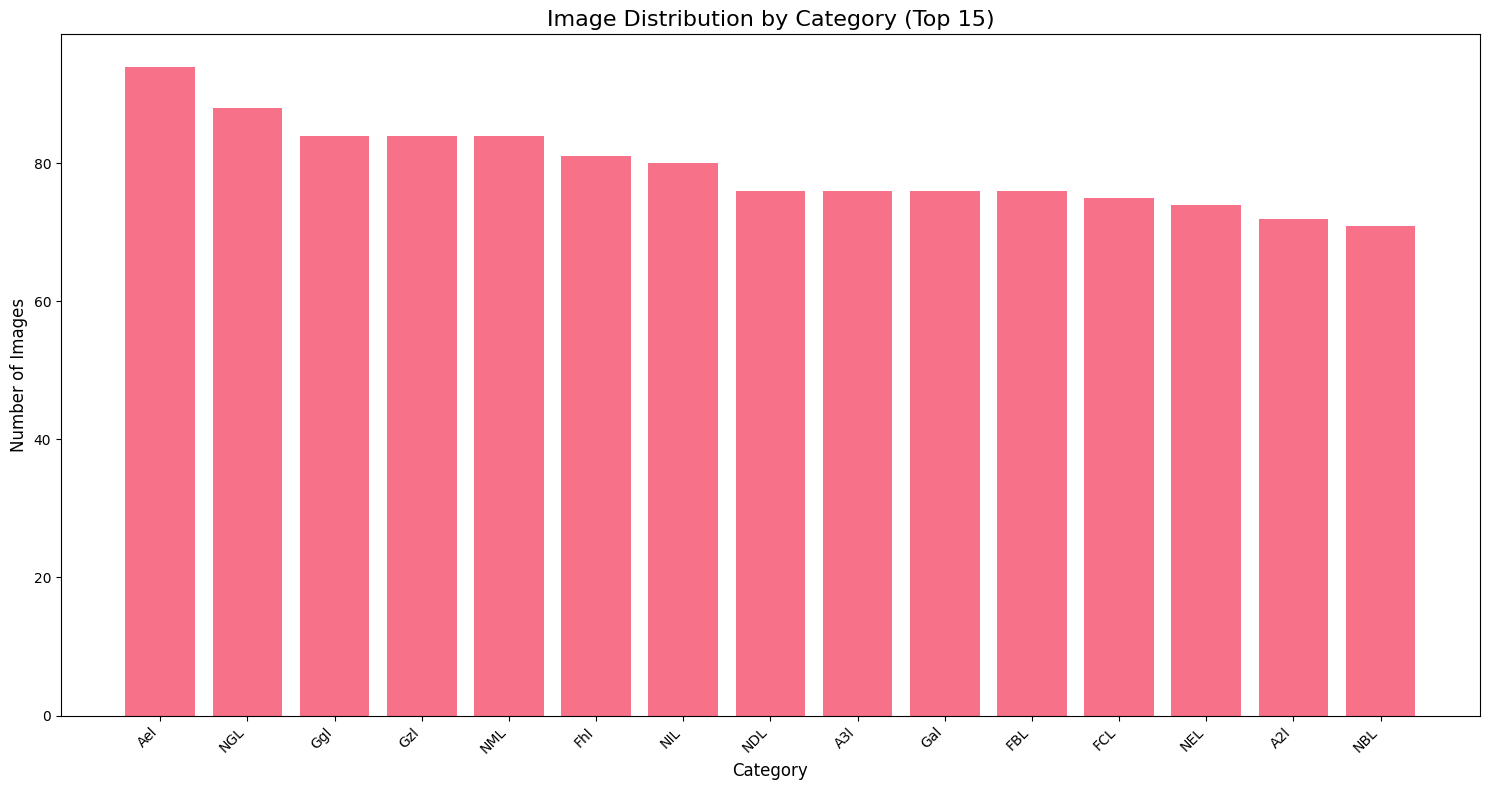

Mean images per category: 57.5
Median images per category: 65.0
Std deviation: 26.8


In [ ]:
# Visualize image distribution by category
plt.figure(figsize=(15, 8))
top_categories = image_counts_df.head(15)
plt.bar(range(len(top_categories)), top_categories['Count'])
plt.xticks(range(len(top_categories)), top_categories['Category'], rotation=45, ha='right')
plt.title('Image Distribution by Category (Top 15)', fontsize=16)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

# Show statistics
print(f"Mean images per category: {image_counts_df['Count'].mean():.1f}")
print(f"Median images per category: {image_counts_df['Count'].median():.1f}")
print(f"Std deviation: {image_counts_df['Count'].std():.1f}")


## 3. Examine Train/Validation/Test Splits


In [ ]:
# Load split files
train_idx = pd.read_csv(meta_dir / "train_indexes.csv")
valid_idx = pd.read_csv(meta_dir / "valid_indexes.csv")
test_idx = pd.read_csv(meta_dir / "test_indexes.csv")

print("Train split shape:", train_idx.shape)
print("Validation split shape:", valid_idx.shape)
print("Test split shape:", test_idx.shape)

print("\nTrain split columns:", train_idx.columns.tolist())
print("Validation split columns:", valid_idx.columns.tolist())
print("Test split columns:", test_idx.columns.tolist())


Train split shape: (413, 1)
Validation split shape: (203, 1)
Test split shape: (395, 1)

Train split columns: ['indexes']
Validation split columns: ['indexes']
Test split columns: ['indexes']


Split sizes:
Train: 413 samples (40.9%)
Validation: 203 samples (20.1%)
Test: 395 samples (39.1%)


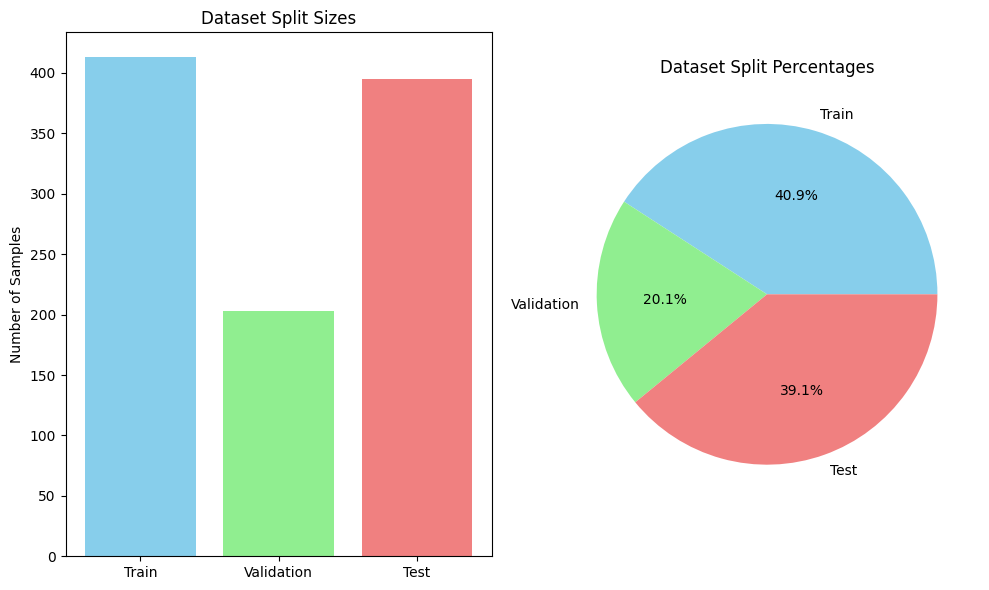

In [ ]:
# Analyze split sizes
split_sizes = {
    'Train': len(train_idx),
    'Validation': len(valid_idx),
    'Test': len(test_idx)
}

total_samples = sum(split_sizes.values())
split_percentages = {k: (v/total_samples)*100 for k, v in split_sizes.items()}

print("Split sizes:")
for split, size in split_sizes.items():
    print(f"{split}: {size} samples ({split_percentages[split]:.1f}%)")

# Visualize split distribution
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.bar(split_sizes.keys(), split_sizes.values(), color=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Dataset Split Sizes')
plt.ylabel('Number of Samples')

plt.subplot(1, 2, 2)
plt.pie(split_sizes.values(), labels=split_sizes.keys(), autopct='%1.1f%%', 
        colors=['skyblue', 'lightgreen', 'lightcoral'])
plt.title('Dataset Split Percentages')

plt.tight_layout()
plt.show()


## 4. Detailed Metadata Analysis


In [ ]:
# Examine specific columns if they exist
print("Available columns in metadata:")
for col in meta_df.columns:
    print(f"- {col}")

# Look for categorical columns
categorical_cols = meta_df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns: {list(categorical_cols)}")

# Analyze categorical variables
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(meta_df[col].value_counts().head(10))


Available columns in metadata:
- case_num
- diagnosis
- seven_point_score
- pigment_network
- streaks
- pigmentation
- regression_structures
- dots_and_globules
- blue_whitish_veil
- vascular_structures
- level_of_diagnostic_difficulty
- elevation
- location
- sex
- management
- clinic
- derm
- case_id
- notes

Categorical columns: ['diagnosis', 'pigment_network', 'streaks', 'pigmentation', 'regression_structures', 'dots_and_globules', 'blue_whitish_veil', 'vascular_structures', 'level_of_diagnostic_difficulty', 'elevation', 'location', 'sex', 'management', 'clinic', 'derm', 'case_id', 'notes']

diagnosis unique values:
diagnosis
clark nevus                     399
melanoma (less than 0.76 mm)    102
reed or spitz nevus              79
melanoma (in situ)               64
melanoma (0.76 to 1.5 mm)        53
seborrheic keratosis             45
basal cell carcinoma             42
dermal nevus                     33
vascular lesion                  29
blue nevus                       28
Na

In [ ]:
# Look for numerical columns that might represent 7-point criteria
numerical_cols = meta_df.select_dtypes(include=[np.number]).columns
print(f"Numerical columns: {list(numerical_cols)}")

if len(numerical_cols) > 0:
    print("\nNumerical column statistics:")
    print(meta_df[numerical_cols].describe())


Numerical columns: ['case_num', 'seven_point_score']

Numerical column statistics:
          case_num  seven_point_score
count  1011.000000        1011.000000
mean    506.000000           2.224530
std     291.994863           2.233417
min       1.000000           0.000000
25%     253.500000           0.000000
50%     506.000000           2.000000
75%     758.500000           4.000000
max    1011.000000          10.000000


## 5. Sample Image Analysis


In [ ]:
# Get a sample of images from different categories
sample_images = []
for subdir in list(images_dir.iterdir())[:5]:  # First 5 categories
    if subdir.is_dir():
        image_files = list(subdir.glob("*.jpg")) + list(subdir.glob("*.JPG"))
        if image_files:
            sample_images.append((subdir.name, image_files[0]))

print("Sample images found:")
for category, image_path in sample_images:
    print(f"Category: {category}, Image: {image_path.name}")


Sample images found:
Category: NAL, Image: Nal058.jpg
Category: NGL, Image: Ngl094.jpg
Category: NFL, Image: Nfl039.jpg
Category: Gal, Image: Gal015.jpg
Category: FDL, Image: Fdl058.jpg


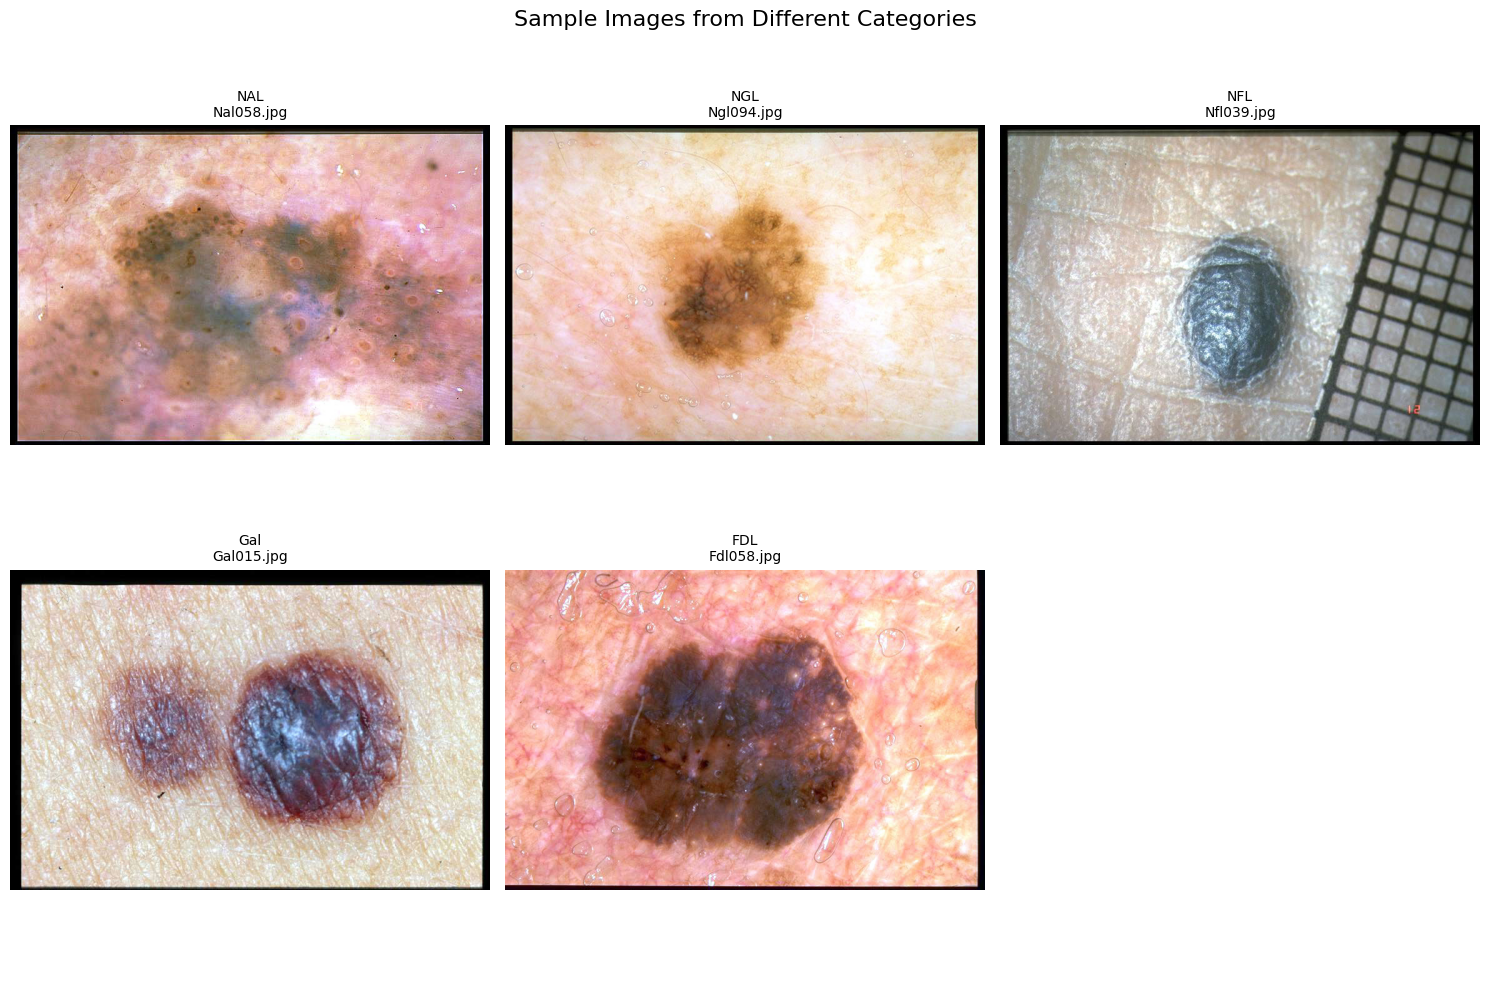

In [ ]:
# Try to load and display sample images
try:
    from PIL import Image
    import matplotlib.patches as patches
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, (category, image_path) in enumerate(sample_images[:6]):
        if i < len(axes):
            try:
                img = Image.open(image_path)
                axes[i].imshow(img)
                axes[i].set_title(f"{category}\n{image_path.name}", fontsize=10)
                axes[i].axis('off')
            except Exception as e:
                axes[i].text(0.5, 0.5, f"Error loading\n{image_path.name}\n{str(e)}", 
                           ha='center', va='center', transform=axes[i].transAxes)
                axes[i].axis('off')
    
    # Hide unused subplots
    for i in range(len(sample_images), len(axes)):
        axes[i].axis('off')
    
    plt.suptitle('Sample Images from Different Categories', fontsize=16)
    plt.tight_layout()
    plt.show()
    
except ImportError:
    print("PIL not available for image display. Install with: pip install Pillow")
except Exception as e:
    print(f"Error displaying images: {e}")


## 6. Dataset Quality and Completeness Analysis


In [ ]:
# Check if all images referenced in metadata actually exist
if 'image' in meta_df.columns:
    missing_images = []
    for idx, row in meta_df.iterrows():
        image_name = row['image']
        # Search for the image in all subdirectories
        found = False
        for subdir in images_dir.iterdir():
            if subdir.is_dir():
                if (subdir / image_name).exists():
                    found = True
                    break
        if not found:
            missing_images.append(image_name)
    
    print(f"Missing images: {len(missing_images)}")
    if missing_images:
        print("First 10 missing images:")
        print(missing_images[:10])
else:
    print("No 'image' column found in metadata")


No 'image' column found in metadata


Total images analyzed: 2013
Average image size: 79.0 KB
Median image size: 78.2 KB
Min image size: 15.5 KB
Max image size: 161.1 KB


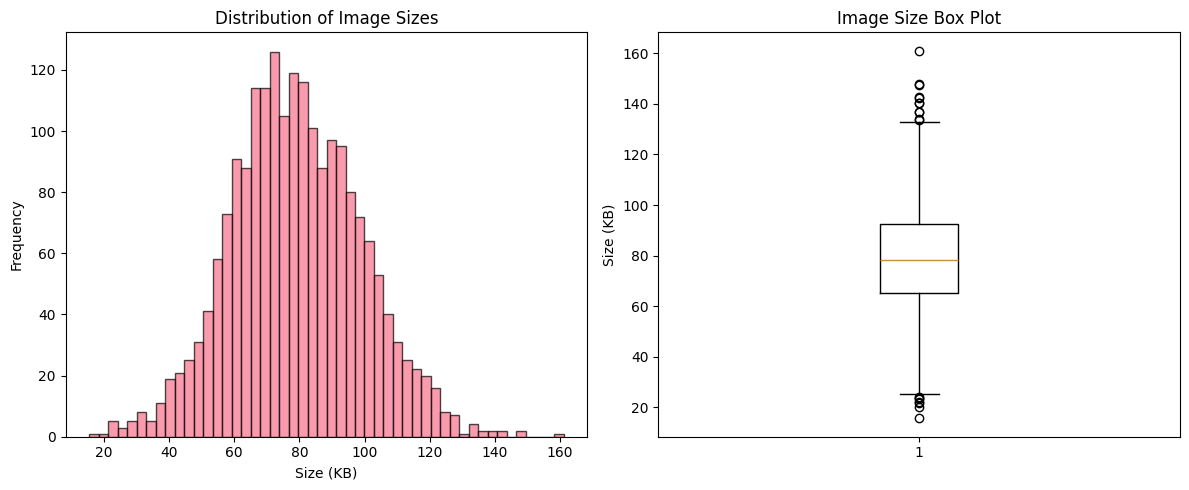

In [ ]:
# Analyze image file sizes and formats
image_info = []
for subdir in images_dir.iterdir():
    if subdir.is_dir():
        for img_file in subdir.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg']:
                try:
                    size = img_file.stat().st_size
                    image_info.append({
                        'category': subdir.name,
                        'filename': img_file.name,
                        'size_bytes': size,
                        'size_kb': size / 1024
                    })
                except:
                    pass

if image_info:
    image_info_df = pd.DataFrame(image_info)
    
    print(f"Total images analyzed: {len(image_info_df)}")
    print(f"Average image size: {image_info_df['size_kb'].mean():.1f} KB")
    print(f"Median image size: {image_info_df['size_kb'].median():.1f} KB")
    print(f"Min image size: {image_info_df['size_kb'].min():.1f} KB")
    print(f"Max image size: {image_info_df['size_kb'].max():.1f} KB")
    
    # Plot image size distribution
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(image_info_df['size_kb'], bins=50, alpha=0.7, edgecolor='black')
    plt.title('Distribution of Image Sizes')
    plt.xlabel('Size (KB)')
    plt.ylabel('Frequency')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(image_info_df['size_kb'])
    plt.title('Image Size Box Plot')
    plt.ylabel('Size (KB)')
    
    plt.tight_layout()
    plt.show()
else:
    print("No image information could be gathered")


## 7. Summary and Insights


In [ ]:
# Generate comprehensive summary
print("=" * 60)
print("DERM7PT DATASET ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total images: {len(image_counts_df)} categories, {image_counts_df['Count'].sum()} images")
print(f"   • Dataset size: ~152 MB (compressed)")
print(f"   • License: CC BY-NC-ND 4.0 (Academic research only)")

print(f"\n📁 CATEGORY DISTRIBUTION:")
print(f"   • Most images: {image_counts_df.iloc[0]['Category']} ({image_counts_df.iloc[0]['Count']} images)")
print(f"   • Least images: {image_counts_df.iloc[-1]['Category']} ({image_counts_df.iloc[-1]['Count']} images)")
print(f"   • Average per category: {image_counts_df['Count'].mean():.1f} images")

print(f"\n🔄 DATA SPLITS:")
for split, size in split_sizes.items():
    print(f"   • {split}: {size} samples ({split_percentages[split]:.1f}%)")

print(f"\n📋 METADATA:")
print(f"   • Columns: {len(meta_df.columns)}")
print(f"   • Rows: {len(meta_df)}")
print(f"   • Missing values: {meta_df.isnull().sum().sum()}")

if 'image_info_df' in locals():
    print(f"\n🖼️ IMAGE CHARACTERISTICS:")
    print(f"   • Average size: {image_info_df['size_kb'].mean():.1f} KB")
    print(f"   • Size range: {image_info_df['size_kb'].min():.1f} - {image_info_df['size_kb'].max():.1f} KB")

print(f"\n✅ DATASET QUALITY:")
print(f"   • Well-organized directory structure")
print(f"   • Pre-defined train/validation/test splits")
print(f"   • Comprehensive metadata available")
print(f"   • Suitable for 7-point criteria melanoma diagnosis research")

print("\n" + "=" * 60)


DERM7PT DATASET ANALYSIS SUMMARY

📊 DATASET OVERVIEW:
   • Total images: 35 categories, 2013 images
   • Dataset size: ~152 MB (compressed)
   • License: CC BY-NC-ND 4.0 (Academic research only)

📁 CATEGORY DISTRIBUTION:
   • Most images: Ael (94 images)
   • Least images: FCl (1 images)
   • Average per category: 57.5 images

🔄 DATA SPLITS:
   • Train: 413 samples (40.9%)
   • Validation: 203 samples (20.1%)
   • Test: 395 samples (39.1%)

📋 METADATA:
   • Columns: 19
   • Rows: 1011
   • Missing values: 1986

🖼️ IMAGE CHARACTERISTICS:
   • Average size: 79.0 KB
   • Size range: 15.5 - 161.1 KB

✅ DATASET QUALITY:
   • Well-organized directory structure
   • Pre-defined train/validation/test splits
   • Comprehensive metadata available
   • Suitable for 7-point criteria melanoma diagnosis research



## 8. Recommendations for Further Analysis

### Next Steps:
1. **Deep Learning Analysis**: Use this dataset for training CNN models for melanoma detection
2. **7-Point Criteria Implementation**: Analyze how well the dataset supports the 7-point criteria evaluation
3. **Cross-Validation**: Implement stratified cross-validation considering the imbalanced categories
4. **Data Augmentation**: Consider augmentation strategies for underrepresented categories
5. **Feature Engineering**: Extract dermatoscopic features relevant to the 7-point criteria

### Potential Challenges:
- **Class Imbalance**: Some categories have significantly fewer images
- **Image Quality**: Variations in image quality and resolution
- **Annotation Consistency**: Ensure consistent application of 7-point criteria

### Useful Resources:
- Original paper and methodology
- GitHub repository: https://github.com/jeremykawahara/derm7pt
- 7-point criteria reference materials
